## **Tutorial 16: Generative Adversarial Networks (GANs)**

This notebook explores the architecture and implementation of Generative Adversarial Networks (GANs) using the PyTorch framework. The primary goal is to train a model to generate synthetic handwritten digits that resemble the MNIST dataset.

---

### **1. Import Libraries**

We start by importing the necessary PyTorch modules for building neural networks, optimizing parameters, and handling the image dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### **2. Load and Prepare MNIST Dataset**

The MNIST dataset consists of 28x28 grayscale images of handwritten digits. We normalize the data to a range of [-1, 1] to match the output of our Generator's activation function.

In [2]:
# MNIST: data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to range [-1, 1]
])

# Load dataset
batch_size = 64
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 56.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.64MB/s]


### **3. Define the Generator**

The Generator's role is to take a vector of random noise (latent dimension) and transform it into a 28x28 image. It uses a series of fully connected layers with ReLU activations, ending with a Tanh function to ensure pixels are in the [-1, 1] range.

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        # Output in range [-1, 1]
        return self.model(z).view(z.size(0), 1, 28, 28)

latent_dim = 100
device = "cuda" if torch.cuda.is_available() else "cpu"
generator = Generator(latent_dim).to(device)

### **4. Define the Discriminator**

The Discriminator is a binary classifier that learns to distinguish between real images from the dataset and fake images produced by the Generator.

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Output probability
        )

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the image
        return self.model(x)

discriminator = Discriminator().to(device)

### **5. Define Loss Function and Optimizers**

We use Binary Cross-Entropy (BCE) loss for both networks. The Adam optimizer is chosen with a specific learning rate to maintain stability during the adversarial training process.

In [5]:
# Loss function
criterion = nn.BCELoss()

# Optimizers
lr = 0.0002
generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

### **6. Training the GAN**

In each epoch, we update the Discriminator to better identify real/fake images and then update the Generator to produce images that can "fool" the Discriminator into classifying them as real.

Epoch [1/50] D Loss: 0.1122 G Loss: 6.5587
Epoch [2/50] D Loss: 0.7792 G Loss: 2.4852
Epoch [3/50] D Loss: 0.1804 G Loss: 3.0549
Epoch [4/50] D Loss: 0.6121 G Loss: 3.3168
Epoch [5/50] D Loss: 0.3465 G Loss: 3.7360
Epoch [6/50] D Loss: 0.7217 G Loss: 2.7965
Epoch [7/50] D Loss: 0.4067 G Loss: 2.7430
Epoch [8/50] D Loss: 0.6063 G Loss: 4.2359
Epoch [9/50] D Loss: 0.4245 G Loss: 3.1169
Epoch [10/50] D Loss: 0.2357 G Loss: 5.8778


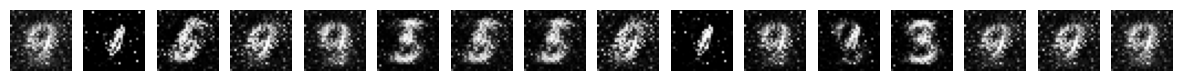

Epoch [11/50] D Loss: 0.1318 G Loss: 3.7238
Epoch [12/50] D Loss: 0.5975 G Loss: 2.9030
Epoch [13/50] D Loss: 0.3431 G Loss: 3.8968
Epoch [14/50] D Loss: 0.1526 G Loss: 4.9675
Epoch [15/50] D Loss: 0.4108 G Loss: 4.1081
Epoch [16/50] D Loss: 0.3720 G Loss: 4.2864
Epoch [17/50] D Loss: 0.2067 G Loss: 4.3493
Epoch [18/50] D Loss: 0.3431 G Loss: 4.0653
Epoch [19/50] D Loss: 0.3734 G Loss: 3.3754
Epoch [20/50] D Loss: 0.4642 G Loss: 3.5824


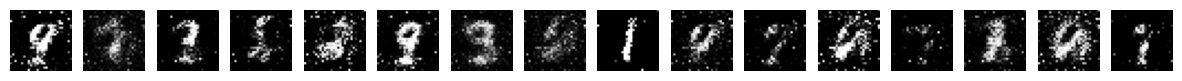

Epoch [21/50] D Loss: 0.3869 G Loss: 2.8467
Epoch [22/50] D Loss: 0.4333 G Loss: 2.9358
Epoch [23/50] D Loss: 0.4310 G Loss: 3.1591
Epoch [24/50] D Loss: 0.3980 G Loss: 3.3254
Epoch [25/50] D Loss: 0.3717 G Loss: 2.7439
Epoch [26/50] D Loss: 0.3462 G Loss: 3.2362
Epoch [27/50] D Loss: 0.5165 G Loss: 2.9876
Epoch [28/50] D Loss: 0.5711 G Loss: 3.5221
Epoch [29/50] D Loss: 0.5299 G Loss: 2.4864
Epoch [30/50] D Loss: 0.7139 G Loss: 1.7508


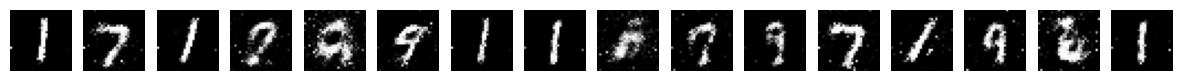

Epoch [31/50] D Loss: 0.3163 G Loss: 2.9101
Epoch [32/50] D Loss: 0.4174 G Loss: 2.7604
Epoch [33/50] D Loss: 0.6874 G Loss: 2.2945
Epoch [34/50] D Loss: 0.8310 G Loss: 1.9616
Epoch [35/50] D Loss: 0.9921 G Loss: 1.5652
Epoch [36/50] D Loss: 0.9712 G Loss: 1.8100
Epoch [37/50] D Loss: 0.7610 G Loss: 2.5845
Epoch [38/50] D Loss: 0.6049 G Loss: 1.9927
Epoch [39/50] D Loss: 0.5429 G Loss: 2.5559
Epoch [40/50] D Loss: 0.9004 G Loss: 2.1578


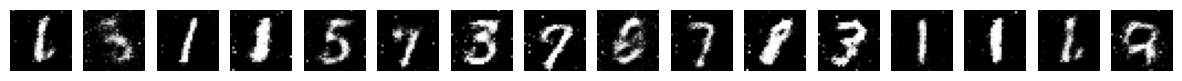

Epoch [41/50] D Loss: 0.7949 G Loss: 1.9941
Epoch [42/50] D Loss: 0.8032 G Loss: 2.3656
Epoch [43/50] D Loss: 0.7608 G Loss: 1.8726
Epoch [44/50] D Loss: 0.9530 G Loss: 1.6996
Epoch [45/50] D Loss: 0.9491 G Loss: 2.4212
Epoch [46/50] D Loss: 0.6787 G Loss: 1.7213
Epoch [47/50] D Loss: 0.8401 G Loss: 2.0405
Epoch [48/50] D Loss: 0.7180 G Loss: 2.0443
Epoch [49/50] D Loss: 0.9733 G Loss: 1.8260
Epoch [50/50] D Loss: 0.9804 G Loss: 1.7352


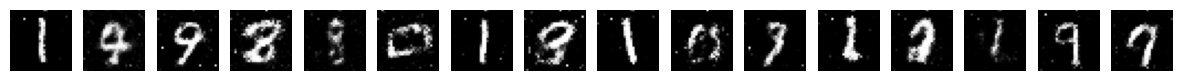

In [6]:
def visualize_images(generator, latent_dim, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, latent_dim).to(device)
    generated_images = generator(noise).detach().cpu()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()
    generator.train()

def train_gan(generator, discriminator, train_loader, epochs, latent_dim):
    for epoch in range(epochs):
        for real_images, _ in train_loader:
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # --- Train Discriminator ---
            discriminator_optimizer.zero_grad()

            # Loss for real images
            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            # Loss for fake images
            noise = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(noise)
            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # --- Train Generator ---
            generator_optimizer.zero_grad()

            # Fool the discriminator
            fake_outputs = discriminator(fake_images)
            g_loss = criterion(fake_outputs, real_labels)

            g_loss.backward()
            generator_optimizer.step()

        # Print losses and visualize progress
        print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.item():.4f} G Loss: {g_loss.item():.4f}")

        if (epoch + 1) % 10 == 0:
            visualize_images(generator, latent_dim)

# Run the training
epochs = 50
train_gan(generator, discriminator, train_loader, epochs, latent_dim)

### **7. Discussion: Training Dynamics**

GAN training is a delicate balancing act known as a "minimax" game.

* **Discriminator's Goal:** Minimize the error in distinguishing real from fake.
* **Generator's Goal:** Maximize the Discriminator's error.
If the Discriminator becomes too strong too quickly, the Generator may fail to learn useful gradients. Conversely, if the Generator is too strong, the Discriminator won't provide useful feedback.

### **8. Generate and Visualize New Images**

Once trained, we can use the Generator independently to produce new digits from random noise.

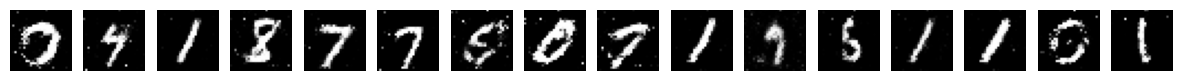

In [7]:
def generate_images(generator, latent_dim, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, latent_dim).to(device)
    generated_images = generator(noise).detach().cpu()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()

# Final generation
generate_images(generator, latent_dim)

# **Task 1 & 2**

 To address Task 1 & 2 from the tutorial, we will modify the network architecture by adding more layers and replacing the fully connected (Linear) layers with convolutional layers. This transition creates a Deep Convolutional GAN (DCGAN), which is significantly more effective for image generation tasks.

100%|██████████| 9.91M/9.91M [00:00<00:00, 131MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 11.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 62.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


Starting Training with Convolutional Layers...
Epoch [1/100] D_Loss: 0.5111 G_Loss: 2.2372


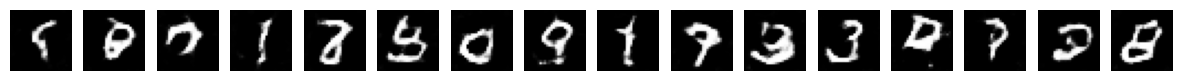

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Configuration & Data Prep (Modified Epochs)
device = "cuda" if torch.cuda.is_available() else "cpu"
epochs = 100  # Increased epochs as per Task 1
batch_size = 64
latent_dim = 100
lr = 0.0002

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 2. DCGAN Generator (Replacing Linear with ConvTranspose2d)
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.model = nn.Sequential(
            # Input is latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State: 256 x 7 x 7
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State: 128 x 14 x 14
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: 1 x 28 x 28
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

# 3. DCGAN Discriminator (Replacing Linear with Conv2d)
class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: 64 x 14 x 14
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # State: 128 x 7 x 7
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

# Initialize Models
generator = DCGenerator(latent_dim).to(device)
discriminator = DCDiscriminator().to(device)
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# 4. Training Loop
print("Starting Training with Convolutional Layers...")
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(train_loader):
        b_size = real_images.size(0)
        real_images = real_images.to(device)
        real_label = torch.ones(b_size, 1).to(device)
        fake_label = torch.zeros(b_size, 1).to(device)

        # Train Discriminator
        discriminator.zero_grad()
        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_label)

        noise = torch.randn(b_size, latent_dim).to(device)
        fake_images = generator(noise)
        output_fake = discriminator(fake_images.detach())
        loss_fake = criterion(output_fake, fake_label)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        generator.zero_grad()
        output_gen = discriminator(fake_images)
        g_loss = criterion(output_gen, real_label)
        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] D_Loss: {d_loss.item():.4f} G_Loss: {g_loss.item():.4f}")
        # Visualizing progress
        generator.eval()
        with torch.no_grad():
            sample_noise = torch.randn(16, latent_dim).to(device)
            samples = generator(sample_noise).cpu()
            fig, axes = plt.subplots(1, 16, figsize=(15, 2))
            for idx in range(16):
                axes[idx].imshow(samples[idx].squeeze(), cmap='gray')
                axes[idx].axis('off')
            plt.show()
        generator.train()